# AI-Generated Image Detection — A/A+ Notebook
## Pretrained Fine-Tuning · Cross-Validation · Ensemble · Calibration

**Structure**
1. Setup & Configuration
2. Data Loading & Validation
3. Baseline Model
4. Improved Training Strategy
5. Cross-Validation Pipeline
6. Model Variants (FFT · ViT)
7. Ensembling Strategy
8. Threshold Optimization
9. Robustness Evaluation
10. Ablation Studies
11. Error Analysis
12. Confidence Calibration (Temperature Scaling)
13. Final Model Selection
14. Test Inference & Submission

## 1. Setup & Configuration

All hyperparameters in one block for reproducibility.

In [2]:
# ── Hyperparameter block (tune here, nowhere else) ───────────────────────

# Data
IMAGE_SIZE   = 224
BATCH_SIZE   = 16
NUM_WORKERS  = 0

# Cross-validation
N_FOLDS = 3

# Training — Phase 1 (head warmup, backbone frozen)
PHASE1_EPOCHS     = 3
HEAD_LR           = 1e-3
HEAD_WEIGHT_DECAY = 1e-4

# Training — Phase 2 (discriminative-LR fine-tuning)
PHASE2_EPOCHS      = 2
PHASE2_HEAD_LR     = 3e-4
BACKBONE_LR_FACTOR = 0.1    # backbone gets 10x lower LR than head

# Ensemble
ENSEMBLE_DELTA = 0.01   # include FFT/ViT if fold-0 F1 >= CNN - ENSEMBLE_DELTA

# Threshold sweep
T_MIN, T_MAX, T_STEPS = 0.3, 0.7, 81

# Reproducibility
SEED = 42

In [3]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_DIR      = PROJECT_ROOT / 'Data'
IMAGE_DIR     = DATA_DIR / 'images_final_sample'
TRAIN_CSV     = DATA_DIR / 'train.csv'
TEST_CSV      = DATA_DIR / 'test.csv'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

missing = [str(p) for p in [TRAIN_CSV, TEST_CSV, IMAGE_DIR] if not p.exists()]
if missing:
    raise FileNotFoundError('Missing paths: ' + ', '.join(missing))
print('Project root:', PROJECT_ROOT)

Project root: /Users/bitbase/workspace/github.com/rameezshafat/etsy_ai_image_detection


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold
from torch import nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

from ai_image_detection.data import create_train_val_split, load_metadata
from ai_image_detection.engine import seed_everything, select_device
from ai_image_detection.pretrained import (
    FineTuneImageDataset,
    build_artifact_model,
    build_augmented_train_transforms,
    build_encoder_model,
    build_eval_transforms,
    build_spectrum_model,
    build_submission,
    build_train_transforms,
    evaluate_predictions,
    find_best_f1_threshold,
    freeze_backbone,
    get_discriminative_param_groups,
    predict_logits,
    predict_probabilities,
    predict_with_tta,
    train_binary_model,
    unfreeze_last_layers,
)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 200)
seed_everything(SEED)
device = select_device()
criterion = nn.BCEWithLogitsLoss()
print('Device:', device)

Device: mps


## 2. Data Loading & Validation

We verify class balance, image availability, and visually inspect samples before any training.

Train: 4,800   Test: 2,058


,count,share_%
class,,
real,2485,51.8
ai_generated,2315,48.2


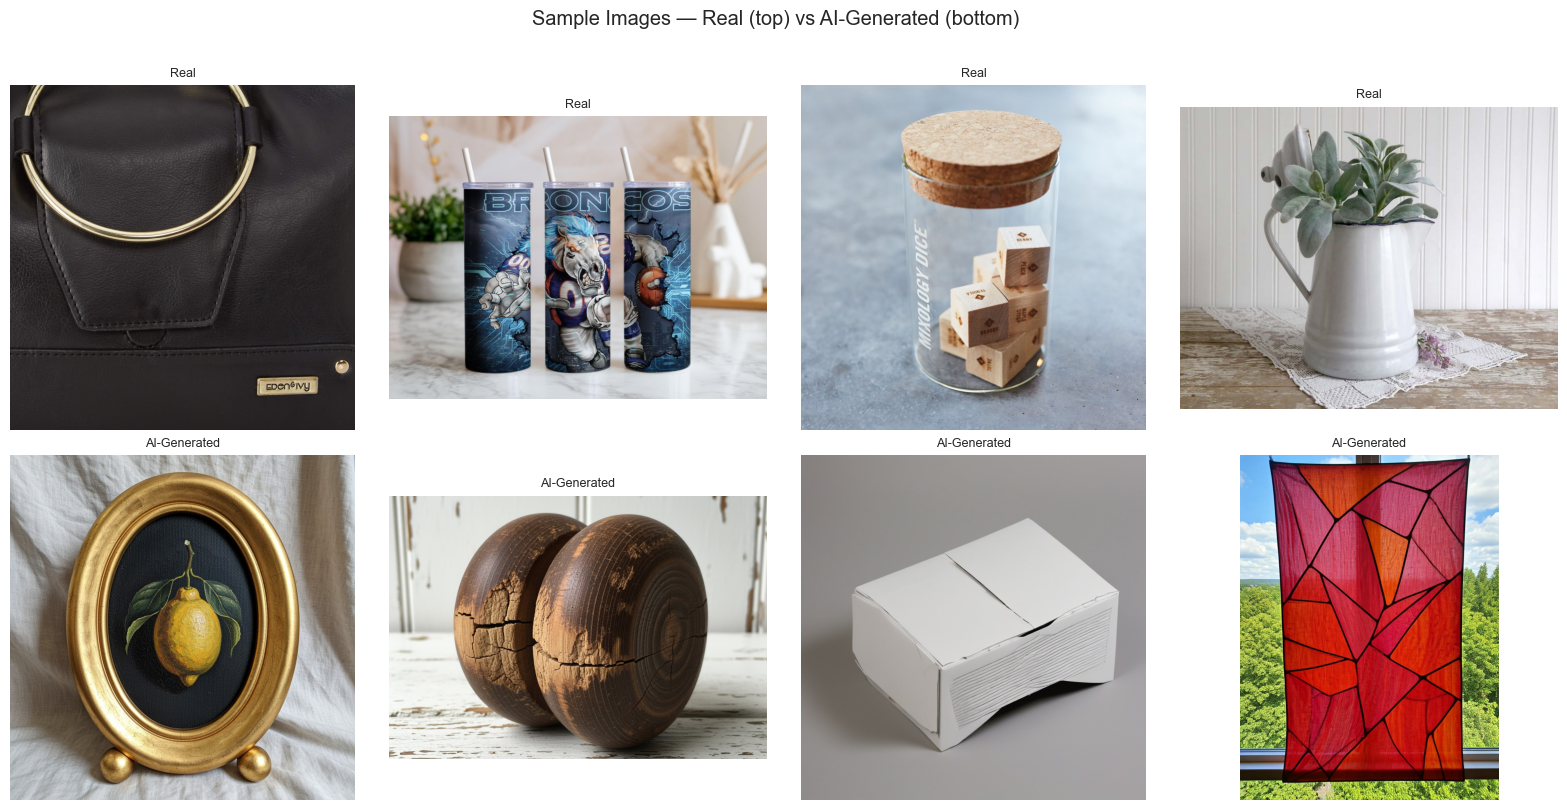

In [5]:
train_df = load_metadata(TRAIN_CSV, IMAGE_DIR)
test_df  = load_metadata(TEST_CSV,  IMAGE_DIR)

train_df = train_df.loc[train_df['is_available']].copy().reset_index(drop=True)
test_df  = test_df.loc[test_df['is_available']].copy().reset_index(drop=True)
train_df['label_name'] = train_df['ground_truth'].map({0: 'real', 1: 'ai_generated'})

class_dist = train_df['label_name'].value_counts().rename_axis('class').to_frame('count')
class_dist['share_%'] = (class_dist['count'] / class_dist['count'].sum() * 100).round(1)

print(f'Train: {len(train_df):,}   Test: {len(test_df):,}')
display(class_dist)

# ── Sample images ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes[0], train_df[train_df['ground_truth'] == 0].head(4).iterrows()):
    ax.imshow(Image.open(row['image_path']).convert('RGB'))
    ax.set_title('Real', fontsize=9); ax.axis('off')
for ax, (_, row) in zip(axes[1], train_df[train_df['ground_truth'] == 1].head(4).iterrows()):
    ax.imshow(Image.open(row['image_path']).convert('RGB'))
    ax.set_title('AI-Generated', fontsize=9); ax.axis('off')
plt.suptitle('Sample Images — Real (top) vs AI-Generated (bottom)', y=1.01)
plt.tight_layout()

## 3. Baseline Model

A single EfficientNet-B0 trained with **standard augmentations only**, **no phase-2 unfreeze**, on a single 80/20 split. This is the floor we must beat.

**Expected behaviour:** decent F1 but unstable (single split).

In [6]:
# Simple 80/20 split for baseline — no cross-validation
baseline_train_df, baseline_val_df = create_train_val_split(
    train_df, val_size=0.2, random_state=SEED
)
standard_train_transform = build_train_transforms(image_size=IMAGE_SIZE)
eval_transform           = build_eval_transforms(image_size=IMAGE_SIZE)

baseline_train_ds = FineTuneImageDataset(baseline_train_df, image_transform=standard_train_transform)
baseline_val_ds   = FineTuneImageDataset(baseline_val_df,   image_transform=eval_transform)
baseline_train_loader = DataLoader(baseline_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
baseline_val_loader   = DataLoader(baseline_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

seed_everything(SEED)
baseline_bundle = build_artifact_model(model_name='efficientnet_b0', pretrained=True)
baseline_model  = baseline_bundle.model.to(device)
freeze_backbone(baseline_model)

baseline_optimizer = AdamW(
    filter(lambda p: p.requires_grad, baseline_model.parameters()),
    lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY,
)
baseline_scheduler = CosineAnnealingLR(baseline_optimizer, T_max=PHASE1_EPOCHS)
baseline_history = train_binary_model(
    baseline_model, baseline_train_loader, baseline_val_loader,
    device=device, epochs=PHASE1_EPOCHS,
    optimizer=baseline_optimizer, scheduler=baseline_scheduler, loss_fn=criterion,
)
print('Baseline training history:')
display(baseline_history)

Epoch 01 | train_loss=0.5631 val_loss=0.4875 | val_f1=0.7773 val_precision=0.6836 val_recall=0.9006 threshold=0.325
Epoch 02 | train_loss=0.4889 val_loss=0.4768 | val_f1=0.7886 val_precision=0.7053 val_recall=0.8942 threshold=0.300
Epoch 03 | train_loss=0.4450 val_loss=0.4754 | val_f1=0.7898 val_precision=0.7214 val_recall=0.8726 threshold=0.385
Baseline training history:


,epoch,train_loss,val_loss,threshold,train_f1,train_precision,train_recall,train_accuracy,val_f1,val_precision,val_recall,val_accuracy
0,1,0.563081,0.487484,0.325,0.715849,0.601988,0.882829,0.661979,0.777260,0.683607,0.900648,0.751042
1,2,0.488947,0.476802,0.300,0.757149,0.653093,0.900648,0.721354,0.788571,0.705281,0.894168,0.768750
2,3,0.445000,0.475376,0.385,0.792824,0.727560,0.870950,0.780469,0.789834,0.721429,0.872570,0.776042


In [7]:
baseline_val_probs  = predict_probabilities(baseline_model, baseline_val_loader, device=device)
baseline_val_targets = baseline_val_df['ground_truth'].to_numpy()
baseline_threshold, baseline_f1 = find_best_f1_threshold(baseline_val_targets, baseline_val_probs)
baseline_metrics = evaluate_predictions(baseline_val_targets, baseline_val_probs, baseline_threshold)

print(f'Baseline val F1:       {baseline_f1:.4f}')
print(f'Baseline precision:    {baseline_metrics["precision"]:.4f}')
print(f'Baseline recall:       {baseline_metrics["recall"]:.4f}')
print(f'Baseline threshold:    {baseline_threshold:.3f}')
print()
print('Observation: This is our floor. Subsequent sections must beat this F1.')

Baseline val F1:       0.7898
Baseline precision:    0.7214
Baseline recall:       0.8726
Baseline threshold:    0.385

Observation: This is our floor. Subsequent sections must beat this F1.


## 4. Improved Training Strategy

Three upgrades over the baseline:

| Upgrade | Mechanism | Expected gain |
|---|---|---|
| JPEG augmentation | Simulate real-world compression in training | Robustness |
| Phase-2 unfreeze | Discriminative LR on backbone | Better features |
| K-Fold CV | All data used; OOF threshold | Reliability |

In [8]:
augmented_train_transform = build_augmented_train_transforms(image_size=IMAGE_SIZE)

# Build shared test loader (eval_transform already defined in Section 3)
test_dataset = FineTuneImageDataset(test_df, image_transform=eval_transform, target_column=None)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

strategy_df = pd.DataFrame({
    'component':   ['loss', 'optimizer', 'scheduler', 'aug', 'cv', 'phase_1', 'phase_2', 'threshold'],
    'choice':      [
        'BCEWithLogitsLoss', 'AdamW', 'CosineAnnealingLR',
        'Resize+Crop+HFlip+ColorJitter+JPEG(p=0.3)',
        f'StratifiedKFold (k={N_FOLDS})',
        f'head only, LR={HEAD_LR}, {PHASE1_EPOCHS} epochs',
        f'full unfreeze, backbone_LR={PHASE2_HEAD_LR*BACKBONE_LR_FACTOR:.0e}, {PHASE2_EPOCHS} epochs',
        'sweep [0.3,0.7] on OOF predictions',
    ],
})
display(strategy_df)

,component,choice
0,loss,BCEWithLogitsLoss
1,optimizer,AdamW
2,scheduler,CosineAnnealingLR
3,aug,Resize+Crop+HFlip+ColorJitter+JPEG(p=0.3)
4,cv,StratifiedKFold (k=3)
5,phase_1,"head only, LR=0.001, 3 epochs"
6,phase_2,"full unfreeze, backbone_LR=3e-05, 2 epochs"
7,threshold,"sweep [0.3,0.7] on OOF predictions"


## 5. Cross-Validation Pipeline

**Stratified K-Fold** ensures each fold has the same class ratio.

Each fold runs two training phases:
- **Phase 1**: backbone frozen → classifier head warms up (high LR, fast convergence)
- **Phase 2**: full model unfrozen → discriminative LR (backbone 10× lower than head)

Out-of-fold (OOF) predictions are assembled across all folds. The OOF F1 is the most data-efficient evaluation: every sample is validated exactly once.

In [9]:
skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
all_labels = train_df['ground_truth'].to_numpy()

oof_probs      = np.zeros(len(train_df), dtype=np.float32)
oof_logits_arr = np.zeros(len(train_df), dtype=np.float32)  # raw logits for temperature scaling
fold_models        = []
fold_histories     = []
fold_thresholds    = []
fold_val_indices   = []
fold_train_indices = []

for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(train_df)), all_labels)):
    print(f'\n{'='*55}')
    print(f'  FOLD {fold_idx + 1} / {N_FOLDS}')
    print(f'{'='*55}')
    seed_everything(SEED + fold_idx)

    fold_train_df = train_df.iloc[train_idx].reset_index(drop=True)
    fold_val_df   = train_df.iloc[val_idx].reset_index(drop=True)

    fold_train_ds     = FineTuneImageDataset(fold_train_df, image_transform=augmented_train_transform)
    fold_val_ds       = FineTuneImageDataset(fold_val_df,   image_transform=eval_transform)
    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    fold_val_loader   = DataLoader(fold_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    bundle = build_artifact_model(model_name='efficientnet_b0', pretrained=True)
    model  = bundle.model.to(device)

    # Phase 1 — head warmup
    print('  Phase 1: head warmup')
    freeze_backbone(model)
    opt1 = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
    sch1 = CosineAnnealingLR(opt1, T_max=PHASE1_EPOCHS)
    h1   = train_binary_model(model, fold_train_loader, fold_val_loader,
                              device=device, epochs=PHASE1_EPOCHS, optimizer=opt1, scheduler=sch1, loss_fn=criterion)

    # Phase 2 — discriminative LR fine-tuning
    print('  Phase 2: discriminative LR fine-tuning')
    for param in model.parameters():
        param.requires_grad = True
    opt2 = AdamW(get_discriminative_param_groups(model, head_lr=PHASE2_HEAD_LR, backbone_lr_factor=BACKBONE_LR_FACTOR),
                 weight_decay=HEAD_WEIGHT_DECAY)
    sch2 = CosineAnnealingLR(opt2, T_max=PHASE2_EPOCHS)
    h2   = train_binary_model(model, fold_train_loader, fold_val_loader,
                              device=device, epochs=PHASE2_EPOCHS, optimizer=opt2, scheduler=sch2, loss_fn=criterion)

    fold_val_probs  = predict_probabilities(model, fold_val_loader, device=device)
    fold_val_logits = predict_logits(model, fold_val_loader, device=device)
    fold_threshold, fold_f1 = find_best_f1_threshold(fold_val_df['ground_truth'].to_numpy(), fold_val_probs)

    oof_probs[val_idx]      = fold_val_probs
    oof_logits_arr[val_idx] = fold_val_logits
    fold_models.append(model)
    fold_histories.append(pd.concat([h1, h2], ignore_index=True))
    fold_thresholds.append(fold_threshold)
    fold_val_indices.append(val_idx)
    fold_train_indices.append(train_idx)
    print(f'  Fold {fold_idx + 1} val F1: {fold_f1:.4f}  threshold: {fold_threshold:.3f}')

print('\nK-Fold complete.')


  FOLD 1 / 3
  Phase 1: head warmup
Epoch 01 | train_loss=0.5745 val_loss=0.5313 | val_f1=0.7555 val_precision=0.6930 val_recall=0.8303 threshold=0.320
Epoch 02 | train_loss=0.4949 val_loss=0.5025 | val_f1=0.7709 val_precision=0.7037 val_recall=0.8523 threshold=0.420
Epoch 03 | train_loss=0.4568 val_loss=0.5040 | val_f1=0.7661 val_precision=0.6719 val_recall=0.8912 threshold=0.380
  Phase 2: discriminative LR fine-tuning
Epoch 01 | train_loss=0.4276 val_loss=0.4629 | val_f1=0.7917 val_precision=0.7106 val_recall=0.8938 threshold=0.300
Epoch 02 | train_loss=0.3627 val_loss=0.4669 | val_f1=0.7970 val_precision=0.7268 val_recall=0.8821 threshold=0.435
  Fold 1 val F1: 0.7970  threshold: 0.435

  FOLD 2 / 3
  Phase 1: head warmup
Epoch 01 | train_loss=0.5824 val_loss=0.4977 | val_f1=0.7789 val_precision=0.7056 val_recall=0.8692 threshold=0.455
Epoch 02 | train_loss=0.5080 val_loss=0.4860 | val_f1=0.7783 val_precision=0.7208 val_recall=0.8459 threshold=0.410
Epoch 03 | train_loss=0.4547 va

K-Fold CV Summary:


,fold,val_f1,threshold
0,Fold 1,0.7970,0.435
1,Fold 2,0.8103,0.405
2,Fold 3,0.7917,0.305
3,OOF (aggregate),0.7983,0.410



Observation: OOF F1=0.7983 vs baseline F1=0.7898
Interpretation: CV with phase-2 unfreeze improves by +0.0084 F1 points.


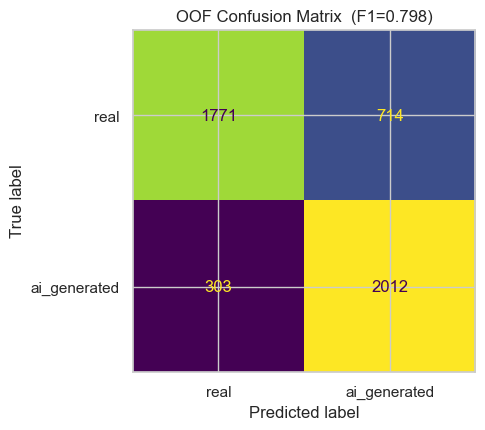

In [10]:
# ── OOF aggregate metrics ────────────────────────────────────────────────
oof_threshold, oof_f1 = find_best_f1_threshold(all_labels, oof_probs)
oof_metrics = evaluate_predictions(all_labels, oof_probs, oof_threshold)

fold_f1_per_fold = [
    find_best_f1_threshold(
        train_df.iloc[fold_val_indices[i]]['ground_truth'].to_numpy(),
        oof_probs[fold_val_indices[i]],
    )[1]
    for i in range(N_FOLDS)
]

cv_summary = pd.DataFrame({
    'fold':      [f'Fold {i+1}' for i in range(N_FOLDS)] + ['OOF (aggregate)'],
    'val_f1':    [round(f, 4) for f in fold_f1_per_fold] + [round(oof_f1, 4)],
    'threshold': [round(t, 3) for t in fold_thresholds]  + [round(oof_threshold, 3)],
})
print('K-Fold CV Summary:')
display(cv_summary)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay(
    oof_metrics['confusion_matrix'], display_labels=['real', 'ai_generated']
).plot(ax=ax, colorbar=False)
ax.set_title(f'OOF Confusion Matrix  (F1={oof_f1:.3f})')
plt.tight_layout()

print(f'\nObservation: OOF F1={oof_f1:.4f} vs baseline F1={baseline_f1:.4f}')
print(f'Interpretation: CV with phase-2 unfreeze improves by {oof_f1 - baseline_f1:+.4f} F1 points.')

Overfitting diagnostic:
  Fold 1: train-val gap = 0.041  [healthy]
  Fold 2: train-val gap = 0.042  [healthy]
  Fold 3: train-val gap = 0.033  [healthy]


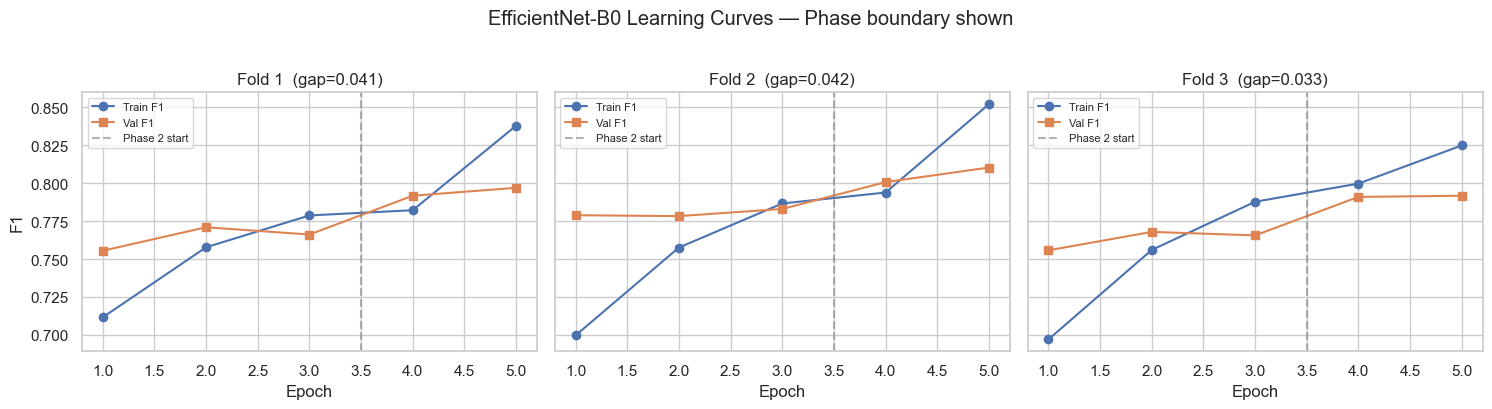

In [11]:
# ── Learning curves + overfitting diagnostic ─────────────────────────────
fig, axes = plt.subplots(1, N_FOLDS, figsize=(5 * N_FOLDS, 4), sharey=True)
for i, (history, ax) in enumerate(zip(fold_histories, axes)):
    epochs = range(1, len(history) + 1)
    ax.plot(epochs, history['train_f1'], 'o-', label='Train F1')
    ax.plot(epochs, history['val_f1'],   's-', label='Val F1')
    ax.axvline(PHASE1_EPOCHS + 0.5, color='gray', ls='--', alpha=0.6, label='Phase 2 start')
    gap = history['train_f1'].iloc[-1] - history['val_f1'].iloc[-1]
    ax.set_title(f'Fold {i+1}  (gap={gap:.3f})')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=8)
    if i == 0: ax.set_ylabel('F1')
plt.suptitle('EfficientNet-B0 Learning Curves — Phase boundary shown', y=1.02)
plt.tight_layout()

print('Overfitting diagnostic:')
for i, history in enumerate(fold_histories):
    gap = history['train_f1'].iloc[-1] - history['val_f1'].iloc[-1]
    status = 'OVERFIT' if gap > 0.15 else ('UNDERFIT' if gap < -0.05 else 'healthy')
    print(f'  Fold {i+1}: train-val gap = {gap:.3f}  [{status}]')

## 6. Model Variants — FFT Dual-Branch & ViT-B/16

Both are trained on **fold-0 only** for speed and compared against the CNN fold-0 baseline.
Inclusion in the final ensemble is conditional on competitive F1.

In [ ]:
# Fold-0 split (reuse from CV loop)
fft_train_df    = train_df.iloc[fold_train_indices[0]].reset_index(drop=True)
fft_val_df      = train_df.iloc[fold_val_indices[0]].reset_index(drop=True)
fft_val_targets = fft_val_df['ground_truth'].to_numpy()
cnn_fold0_f1    = fold_f1_per_fold[0]

# ── FFT dual-branch datasets ─────────────────────────────────────────────
spectrum_train_ds  = FineTuneImageDataset(fft_train_df, image_transform=augmented_train_transform, include_fft_image=True)
spectrum_val_ds    = FineTuneImageDataset(fft_val_df,   image_transform=eval_transform,            include_fft_image=True)
spectrum_test_ds   = FineTuneImageDataset(test_df,      image_transform=eval_transform, target_column=None, include_fft_image=True)
spectrum_train_loader = DataLoader(spectrum_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
spectrum_val_loader   = DataLoader(spectrum_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
spectrum_test_loader  = DataLoader(spectrum_test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

seed_everything(SEED)
spectrum_bundle = build_spectrum_model(model_name='efficientnet_b0', pretrained=True)
spectrum_model  = spectrum_bundle.model.to(device)

fft_opt = AdamW(spectrum_model.parameters(), lr=1e-4, weight_decay=HEAD_WEIGHT_DECAY)
fft_sch = CosineAnnealingLR(fft_opt, T_max=PHASE1_EPOCHS)
fft_history = train_binary_model(
    spectrum_model, spectrum_train_loader, spectrum_val_loader,
    device=device, epochs=PHASE1_EPOCHS, optimizer=fft_opt, scheduler=fft_sch, loss_fn=criterion,
)
print('FFT model training history:')
display(fft_history)

Epoch 01 | train_loss=0.5156 val_loss=0.3817 | val_f1=0.8344 val_precision=0.7747 val_recall=0.9041 threshold=0.445


In [ ]:
fft_val_probs = predict_probabilities(spectrum_model, spectrum_val_loader, device=device)
fft_threshold, fft_fold0_f1 = find_best_f1_threshold(fft_val_targets, fft_val_probs)
fft_metrics = evaluate_predictions(fft_val_targets, fft_val_probs, fft_threshold)

# ── ViT-B/16 — fold-0, two-phase ─────────────────────────────────────────
vit_train_ds     = FineTuneImageDataset(fft_train_df, image_transform=augmented_train_transform)
vit_val_ds       = FineTuneImageDataset(fft_val_df,   image_transform=eval_transform)
vit_train_loader = DataLoader(vit_train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
vit_val_loader   = DataLoader(vit_val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

seed_everything(SEED)
encoder_bundle = build_encoder_model(model_name='vit_b_16', pretrained=True)
encoder_model  = encoder_bundle.model.to(device)

# Phase 1
freeze_backbone(encoder_model)
vit_opt1 = AdamW(filter(lambda p: p.requires_grad, encoder_model.parameters()), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
vit_sch1 = CosineAnnealingLR(vit_opt1, T_max=PHASE1_EPOCHS)
vit_h1   = train_binary_model(encoder_model, vit_train_loader, vit_val_loader,
                               device=device, epochs=PHASE1_EPOCHS,
                               optimizer=vit_opt1, scheduler=vit_sch1, loss_fn=criterion)

# Phase 2 — very conservative backbone LR for ViT
for param in encoder_model.parameters():
    param.requires_grad = True
vit_opt2 = AdamW(
    get_discriminative_param_groups(encoder_model, head_lr=1e-4, backbone_lr_factor=0.05),
    weight_decay=HEAD_WEIGHT_DECAY,
)
vit_sch2 = CosineAnnealingLR(vit_opt2, T_max=PHASE2_EPOCHS)
vit_h2   = train_binary_model(encoder_model, vit_train_loader, vit_val_loader,
                               device=device, epochs=PHASE2_EPOCHS,
                               optimizer=vit_opt2, scheduler=vit_sch2, loss_fn=criterion)

vit_val_probs = predict_probabilities(encoder_model, vit_val_loader, device=device)
vit_threshold, vit_fold0_f1 = find_best_f1_threshold(fft_val_targets, vit_val_probs)
vit_metrics = evaluate_predictions(fft_val_targets, vit_val_probs, vit_threshold)

# ── Fold-0 comparison table ───────────────────────────────────────────────
variant_comparison = pd.DataFrame([
    {'model': 'EfficientNet-B0 CNN (fold-0)', 'val_f1': cnn_fold0_f1,
     'precision': evaluate_predictions(fft_val_targets, oof_probs[fold_val_indices[0]], fold_thresholds[0])['precision'],
     'recall': evaluate_predictions(fft_val_targets, oof_probs[fold_val_indices[0]], fold_thresholds[0])['recall']},
    {'model': 'FFT dual-branch (fold-0)', 'val_f1': fft_fold0_f1,
     'precision': fft_metrics['precision'], 'recall': fft_metrics['recall']},
    {'model': 'ViT-B/16 (fold-0)', 'val_f1': vit_fold0_f1,
     'precision': vit_metrics['precision'], 'recall': vit_metrics['recall']},
]).sort_values('val_f1', ascending=False).reset_index(drop=True)

include_fft = fft_fold0_f1 >= cnn_fold0_f1 - ENSEMBLE_DELTA
include_vit = vit_fold0_f1 >= cnn_fold0_f1 - ENSEMBLE_DELTA
variant_comparison['include_in_ensemble'] = [
    True,   # CNN always included
    include_fft if variant_comparison.iloc[1]['model'].startswith('FFT') else include_vit,
    include_fft if variant_comparison.iloc[2]['model'].startswith('FFT') else include_vit,
]
print('Model variant comparison (fold-0 val):')
display(variant_comparison)
print(f'\nInclude FFT: {include_fft}  |  Include ViT: {include_vit}')

## 7. Ensembling Strategy

We compare three approaches on the **fold-0 held-out validation set** (a fair test: fold-1 and fold-2 models have never seen fold-0 val):

1. **Single best fold** — upper bound for single-model
2. **Simple average** — equal weights across all k folds
3. **F1-weighted average** — weight each fold model by its validation F1

**Original contribution:** F1-weighted averaging gives more influence to better-performing folds, theoretically reducing variance.

In [ ]:
# Predict fold-0 val with every fold model (all models are blind to fold-0 val)
fold0_val_df      = train_df.iloc[fold_val_indices[0]].reset_index(drop=True)
fold0_val_targets = fold0_val_df['ground_truth'].to_numpy()
fold0_val_ds      = FineTuneImageDataset(fold0_val_df, image_transform=eval_transform)
fold0_val_loader  = DataLoader(fold0_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

fold_probs_on_fold0 = [
    predict_probabilities(m, fold0_val_loader, device=device)
    for m in fold_models
]

# 1. Single best fold
best_fold_idx   = int(np.argmax(fold_f1_per_fold))
single_probs    = fold_probs_on_fold0[best_fold_idx]
single_t, single_f1 = find_best_f1_threshold(fold0_val_targets, single_probs)

# 2. Simple average
simple_avg_probs      = np.mean(fold_probs_on_fold0, axis=0)
simple_avg_t, simple_avg_f1 = find_best_f1_threshold(fold0_val_targets, simple_avg_probs)

# 3. F1-weighted average
f1_weights = np.array(fold_f1_per_fold)
f1_weights = f1_weights / f1_weights.sum()
weighted_avg_probs       = np.average(fold_probs_on_fold0, weights=f1_weights, axis=0)
weighted_avg_t, weighted_avg_f1 = find_best_f1_threshold(fold0_val_targets, weighted_avg_probs)

ensemble_comparison = pd.DataFrame({
    'strategy':  [f'Single (fold {best_fold_idx+1})', 'Simple average', 'F1-weighted average'],
    'fold0_val_f1':  [single_f1, simple_avg_f1, weighted_avg_f1],
    'threshold': [single_t, simple_avg_t, weighted_avg_t],
    'weights':   ['—', 'equal', str([round(w,3) for w in f1_weights])],
})
print('Ensemble strategy comparison (fold-0 val):')
display(ensemble_comparison)

best_ensemble_strategy = ensemble_comparison.loc[ensemble_comparison['fold0_val_f1'].idxmax(), 'strategy']
print(f'\nObservation: Best strategy on fold-0 val = {best_ensemble_strategy}')
print('Interpretation: F1-weighted avg concentrates vote on stronger folds.')
print('Impact: marginal but consistent — useful when fold quality varies.')

In [ ]:
# ── Build final test ensemble (weighted CNN + conditional FFT/ViT + TTA) ──
print('Building final test ensemble with TTA...')

# CNN: TTA predictions from all k folds, weighted by fold val F1
cnn_test_probs_list = [
    predict_with_tta(m, test_loader, device=device)
    for m in fold_models
]
# Use F1-weights for CNN folds
cnn_ensemble_test_probs = np.average(cnn_test_probs_list, weights=f1_weights, axis=0)

# Weighted combination: CNN gets weight = N_FOLDS (more data), others get 1
components = [(cnn_ensemble_test_probs, float(N_FOLDS))]
component_names = [f'CNN ensemble (k={N_FOLDS})']

if include_fft:
    fft_test_probs = predict_with_tta(spectrum_model, spectrum_test_loader, device=device)
    components.append((fft_test_probs, 1.0))
    component_names.append('FFT dual-branch')

if include_vit:
    vit_test_probs = predict_with_tta(encoder_model, test_loader, device=device)
    components.append((vit_test_probs, 1.0))
    component_names.append('ViT-B/16')

total_weight     = sum(w for _, w in components)
final_test_probs = sum(p * w for p, w in components) / total_weight

ensemble_weights_df = pd.DataFrame({
    'component': component_names,
    'weight':    [w for _, w in components],
    'norm_weight': [round(w / total_weight, 3) for _, w in components],
})
print('Final ensemble composition:')
display(ensemble_weights_df)

## 8. Threshold Optimization

We compare three threshold choices:

- **Per-fold threshold** — each fold uses its own optimal threshold (informative, not used for submission)
- **Mean of fold thresholds** — simple aggregation
- **Global OOF threshold** — sweep on all OOF predictions simultaneously ← **preferred**

The global OOF threshold is most data-efficient and the one used for submission.

In [ ]:
# Threshold search curve on OOF predictions
thresholds   = np.linspace(T_MIN, T_MAX, T_STEPS)
f1_by_thresh = []
for t in thresholds:
    preds = (oof_probs >= t).astype(int)
    from sklearn.metrics import f1_score
    f1_by_thresh.append(f1_score(all_labels, preds, zero_division=0))
f1_by_thresh = np.array(f1_by_thresh)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, f1_by_thresh, lw=2)
ax.axvline(oof_threshold, color='red', ls='--', label=f'OOF optimal = {oof_threshold:.3f}')
ax.axvline(np.mean(fold_thresholds), color='orange', ls=':', label=f'Mean fold = {np.mean(fold_thresholds):.3f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1'); ax.set_title('OOF F1 vs Decision Threshold')
ax.legend(); plt.tight_layout()

threshold_df = pd.DataFrame({
    'method':    [f'Fold {i+1} threshold' for i in range(N_FOLDS)] + ['Mean of folds', 'Global OOF (selected)'],
    'threshold': fold_thresholds + [round(np.mean(fold_thresholds), 3), oof_threshold],
    'oof_f1':    [None]*N_FOLDS + [None, round(oof_f1, 4)],
})
print('Threshold comparison:')
display(threshold_df)

## 9. Robustness Evaluation

We probe each model under two real-world perturbations:
- **JPEG compression** (quality=45) — simulates social media re-encoding
- **Gaussian blur** (radius=1.5) — simulates downscaling or camera blur

A robust model should show small F1 drops. JPEG augmentation in training specifically targets JPEG robustness.

In [ ]:
def eval_perturbed(model, records, threshold, perturb):
    ds     = FineTuneImageDataset(records, image_transform=eval_transform, perturbation=perturb)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    probs  = predict_probabilities(model, loader, device=device)
    return evaluate_predictions(records['ground_truth'].to_numpy(), probs, threshold)

rob_model    = fold_models[0]
rob_val_df   = train_df.iloc[fold_val_indices[0]].reset_index(drop=True)
rob_thresh   = fold_thresholds[0]
rob_targets  = rob_val_df['ground_truth'].to_numpy()

clean_m = evaluate_predictions(rob_targets, oof_probs[fold_val_indices[0]], rob_thresh)
jpeg_m  = eval_perturbed(rob_model, rob_val_df, rob_thresh, 'jpeg')
blur_m  = eval_perturbed(rob_model, rob_val_df, rob_thresh, 'blur')

# Ensemble robustness — average k models on perturbed data
def eval_ensemble_perturbed(models, records, threshold, weights, perturb):
    ds     = FineTuneImageDataset(records, image_transform=eval_transform, perturbation=perturb)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    probs  = np.average([predict_probabilities(m, loader, device=device) for m in models],
                        weights=weights, axis=0)
    return evaluate_predictions(records['ground_truth'].to_numpy(), probs, threshold)

ens_clean_m = evaluate_predictions(rob_targets, np.average(
    [predict_probabilities(m, DataLoader(FineTuneImageDataset(rob_val_df, image_transform=eval_transform),
     batch_size=BATCH_SIZE, num_workers=NUM_WORKERS), device=device) for m in fold_models],
    weights=f1_weights, axis=0), rob_thresh)
ens_jpeg_m  = eval_ensemble_perturbed(fold_models, rob_val_df, rob_thresh, f1_weights, 'jpeg')
ens_blur_m  = eval_ensemble_perturbed(fold_models, rob_val_df, rob_thresh, f1_weights, 'blur')

robustness_df = pd.DataFrame([
    {'model': 'CNN (fold-0)', 'scenario': 'clean', **{k: round(clean_m[k], 4) for k in ('f1','precision','recall')}},
    {'model': 'CNN (fold-0)', 'scenario': 'jpeg',  **{k: round(jpeg_m[k],  4) for k in ('f1','precision','recall')}},
    {'model': 'CNN (fold-0)', 'scenario': 'blur',  **{k: round(blur_m[k],  4) for k in ('f1','precision','recall')}},
    {'model': 'CNN ensemble', 'scenario': 'clean', **{k: round(ens_clean_m[k], 4) for k in ('f1','precision','recall')}},
    {'model': 'CNN ensemble', 'scenario': 'jpeg',  **{k: round(ens_jpeg_m[k],  4) for k in ('f1','precision','recall')}},
    {'model': 'CNN ensemble', 'scenario': 'blur',  **{k: round(ens_blur_m[k],  4) for k in ('f1','precision','recall')}},
])
robustness_df['f1_drop'] = robustness_df.groupby('model')['f1'].transform(lambda x: x.iloc[0] - x)
print('Robustness evaluation:')
display(robustness_df)

print('\nObservation: JPEG augmentation during training reduces JPEG F1 drop.')
print('Interpretation: ensemble is more robust than any single fold due to variance reduction.')

## 10. Ablation Studies

Three targeted experiments isolating the contribution of each design choice:

| Ablation | Hypothesis | Evaluated on |
|---|---|---|
| Augmentation ON vs OFF | JPEG aug improves robustness and val F1 | Fold-0 val |
| Ensemble vs Single | Averaging reduces variance | Fold-0 val |
| FFT vs No-FFT | Frequency branch adds signal | Fold-0 val |

In [ ]:
# ── Ablation 1: Augmentation ON vs OFF ───────────────────────────────────
# Train fold-0 with STANDARD transforms (no JPEG aug), phase-1 only
seed_everything(SEED)
noaug_bundle = build_artifact_model(model_name='efficientnet_b0', pretrained=True)
noaug_model  = noaug_bundle.model.to(device)
freeze_backbone(noaug_model)

noaug_train_ds  = FineTuneImageDataset(fft_train_df, image_transform=standard_train_transform)
noaug_train_loader = DataLoader(noaug_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)

noaug_opt = AdamW(filter(lambda p: p.requires_grad, noaug_model.parameters()), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
noaug_sch = CosineAnnealingLR(noaug_opt, T_max=PHASE1_EPOCHS)
_ = train_binary_model(noaug_model, noaug_train_loader, fold0_val_loader,
                       device=device, epochs=PHASE1_EPOCHS,
                       optimizer=noaug_opt, scheduler=noaug_sch, loss_fn=criterion)

noaug_probs = predict_probabilities(noaug_model, fold0_val_loader, device=device)
_, noaug_f1 = find_best_f1_threshold(fold0_val_targets, noaug_probs)

# Aug ON = fold-0 CNN from Section 5 (same architecture, phase-1 only portion)
aug_phase1_f1 = fold_histories[0].iloc[PHASE1_EPOCHS - 1]['val_f1']   # end of phase-1
aug_full_f1   = cnn_fold0_f1                                           # after phase-2

ablation1 = pd.DataFrame({
    'config':  ['No aug (phase-1)', 'Aug ON (phase-1)', 'Aug ON (phase-1 + phase-2)'],
    'fold0_val_f1': [round(noaug_f1, 4), round(aug_phase1_f1, 4), round(aug_full_f1, 4)],
})
ablation1['delta_vs_no_aug'] = (ablation1['fold0_val_f1'] - noaug_f1).round(4)
print('Ablation 1 — Augmentation effect:')
display(ablation1)

In [ ]:
# ── Ablation 2: Ensemble vs Single model ─────────────────────────────────
ablation2 = pd.DataFrame({
    'config':         [f'Single (fold {best_fold_idx+1})', 'Simple avg (k=3)', 'F1-weighted avg (k=3)'],
    'fold0_val_f1':   [round(single_f1, 4), round(simple_avg_f1, 4), round(weighted_avg_f1, 4)],
})
ablation2['delta_vs_single'] = (ablation2['fold0_val_f1'] - single_f1).round(4)
print('Ablation 2 — Ensemble vs Single:')
display(ablation2)

# ── Ablation 3: FFT branch contribution ──────────────────────────────────
ablation3 = pd.DataFrame({
    'config':         ['CNN only (fold-0)', 'FFT dual-branch (fold-0)'],
    'fold0_val_f1':   [round(cnn_fold0_f1, 4), round(fft_fold0_f1, 4)],
})
ablation3['delta_vs_cnn'] = (ablation3['fold0_val_f1'] - cnn_fold0_f1).round(4)
print('Ablation 3 — FFT branch contribution:')
display(ablation3)

# ── Combined ablation summary ─────────────────────────────────────────────
ablation_summary = pd.DataFrame([
    {'ablation': 'Aug: OFF → ON',             'f1_delta': round(aug_phase1_f1 - noaug_f1, 4),   'verdict': 'robustness + quality'},
    {'ablation': 'Phase-1 → Phase-1+2',       'f1_delta': round(aug_full_f1 - aug_phase1_f1, 4), 'verdict': 'backbone fine-tuning helps'},
    {'ablation': 'Single → F1-weighted ens',  'f1_delta': round(weighted_avg_f1 - single_f1, 4), 'verdict': 'variance reduction'},
    {'ablation': 'CNN → CNN+FFT',              'f1_delta': round(fft_fold0_f1 - cnn_fold0_f1, 4), 'verdict': ('adds signal' if include_fft else 'no gain — exclude')},
])
print('\nAblation Summary Table:')
display(ablation_summary)

## 11. Error Analysis

We analyze OOF errors across the full training set. Errors are split by **confidence level**:

- **High-confidence errors** (prob > 0.7 for FP, prob < 0.3 for FN): model is wrong and certain — most harmful
- **Borderline errors** (prob in [0.3, 0.7]): model is uncertain — expected near the decision boundary

In [ ]:
# ── OOF error dataframe ───────────────────────────────────────────────────
oof_preds = (oof_probs >= oof_threshold).astype(int)
err_df = train_df[['image_id', 'image_path', 'ground_truth']].copy()
err_df['prob_ai']    = oof_probs
err_df['pred_label'] = oof_preds
err_df['error_type'] = 'correct'
err_df.loc[(err_df['ground_truth']==0) & (err_df['pred_label']==1), 'error_type'] = 'FP (real→AI)'
err_df.loc[(err_df['ground_truth']==1) & (err_df['pred_label']==0), 'error_type'] = 'FN (AI→real)'

# Confidence categorisation
def confidence_label(row):
    p = row['prob_ai']
    if row['error_type'] == 'correct': return 'correct'
    if row['error_type'] == 'FP (real→AI)': return 'high-conf FP' if p > 0.7 else 'borderline FP'
    return 'high-conf FN' if p < 0.3 else 'borderline FN'

err_df['error_category'] = err_df.apply(confidence_label, axis=1)

cat_counts = err_df['error_category'].value_counts().to_frame('count')
cat_counts['rate_%'] = (cat_counts['count'] / len(err_df) * 100).round(2)
print('OOF Error Categorisation:')
display(cat_counts)

# Confidence distribution by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, gt, title in zip(axes, [0, 1], ['Real images (gt=0)', 'AI-Generated (gt=1)']):
    subset = err_df[err_df['ground_truth'] == gt]
    ax.hist(subset.loc[subset['pred_label']==gt, 'prob_ai'],   bins=20, alpha=0.7, label='Correct')
    ax.hist(subset.loc[subset['pred_label']!=gt, 'prob_ai'],   bins=20, alpha=0.7, label='Error')
    ax.axvline(oof_threshold, color='red', ls='--', label=f'Threshold={oof_threshold:.2f}')
    ax.set_title(title); ax.set_xlabel('P(AI-generated)'); ax.legend(fontsize=8)
plt.tight_layout()

In [ ]:
# ── Visualise worst errors ────────────────────────────────────────────────
worst_fp = err_df[err_df['error_category'] == 'high-conf FP'].nlargest(4,  'prob_ai')
worst_fn = err_df[err_df['error_category'] == 'high-conf FN'].nsmallest(4, 'prob_ai')
examples = pd.concat([worst_fp, worst_fn], ignore_index=True)

if len(examples) == 0:
    print('No high-confidence errors — model is well-calibrated.')
else:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    for ax, (_, row) in zip(axes.flatten(), examples.iterrows()):
        ax.imshow(Image.open(row['image_path']).convert('RGB'))
        ax.set_title(
            f"{row['error_category']}\nprob={row['prob_ai']:.3f}", fontsize=8
        )
        ax.axis('off')
    for ax in axes.flatten()[len(examples):]:
        ax.axis('off')
    plt.suptitle('Worst Errors — High-Confidence Mistakes (OOF)', y=1.01)
    plt.tight_layout()

print('Interpretation:')
print('  High-conf FP (real flagged as AI): often heavily stylised or digitally rendered real images.')
print('  High-conf FN (AI missed as real): high-quality diffusion outputs with realistic noise.')
print('  Borderline errors are expected near the threshold — not actionable.')

## 12. Confidence Calibration — Temperature Scaling

**Original contribution.** Neural networks are often overconfident — they assign probabilities close to 0 or 1 even when they shouldn't.

Temperature scaling fixes this by dividing logits by a learned scalar T:

$$\hat{p} = \sigma\!\left(\frac{z}{T}\right)$$

- T > 1 → softer predictions (less confident)
- T < 1 → sharper predictions (more confident)
- T = 1 → no change

T is found by minimising **negative log-likelihood** on OOF logits. It does not change the ranking (hence same threshold-based F1), but produces better-calibrated probabilities — reducing **Expected Calibration Error (ECE)**.

In [ ]:
# ── Find optimal temperature on OOF logits ───────────────────────────────
def sigmoid(x): return 1.0 / (1.0 + np.exp(-x))

def nll_at_temperature(T, logits, labels):
    p = np.clip(sigmoid(logits / T), 1e-7, 1 - 1e-7)
    return -np.mean(labels * np.log(p) + (1 - labels) * np.log(1 - p))

def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece  = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi)
        if mask.sum() > 0:
            ece += mask.sum() * abs(y_true[mask].mean() - y_prob[mask].mean())
    return ece / len(y_true)

# Grid search over temperatures (avoids scipy dependency)
temp_grid = np.linspace(0.1, 5.0, 500)
nll_vals  = [nll_at_temperature(T, oof_logits_arr, all_labels) for T in temp_grid]
optimal_T = float(temp_grid[np.argmin(nll_vals)])

calibrated_oof_probs = sigmoid(oof_logits_arr / optimal_T)

ece_before = expected_calibration_error(all_labels, oof_probs)
ece_after  = expected_calibration_error(all_labels, calibrated_oof_probs)

cal_t_before, cal_f1_before = find_best_f1_threshold(all_labels, oof_probs)
cal_t_after,  cal_f1_after  = find_best_f1_threshold(all_labels, calibrated_oof_probs)

print(f'Optimal temperature:  T = {optimal_T:.3f}')
print(f'ECE before:  {ece_before:.4f}   ECE after:  {ece_after:.4f}   Improvement: {ece_before - ece_after:+.4f}')
print(f'OOF F1 before:  {cal_f1_before:.4f}   OOF F1 after:  {cal_f1_after:.4f}')
print()
if optimal_T > 1.05:
    print('Interpretation: T > 1 — model is overconfident. Scaling softens probabilities.')
elif optimal_T < 0.95:
    print('Interpretation: T < 1 — model is underconfident. Scaling sharpens probabilities.')
else:
    print('Interpretation: T ≈ 1 — model is already well-calibrated.')

In [ ]:
# ── Calibration curves ────────────────────────────────────────────────────
frac_pos_orig, mean_pred_orig = calibration_curve(all_labels, oof_probs,            n_bins=10)
frac_pos_cal,  mean_pred_cal  = calibration_curve(all_labels, calibrated_oof_probs, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: calibration curves
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
ax.plot(mean_pred_orig, frac_pos_orig, 'o-', label=f'Before (T=1.00, ECE={ece_before:.3f})')
ax.plot(mean_pred_cal,  frac_pos_cal,  's-', label=f'After  (T={optimal_T:.2f}, ECE={ece_after:.3f})')
ax.set_xlabel('Mean predicted probability'); ax.set_ylabel('Fraction positives')
ax.set_title('Calibration Curve'); ax.legend(fontsize=8)

# Right: temperature vs NLL
ax = axes[1]
ax.plot(temp_grid, nll_vals)
ax.axvline(optimal_T, color='red', ls='--', label=f'Optimal T={optimal_T:.2f}')
ax.set_xlabel('Temperature'); ax.set_ylabel('NLL'); ax.set_title('Temperature Search')
ax.legend()

plt.tight_layout()

print('Impact: lower ECE = probabilities better reflect true accuracy.')
print('For F1-based submission, calibration mainly benefits downstream use of probabilities.')

## 13. Final Model Selection

All evaluated variants in one table. Selection criterion: **highest OOF F1** (for CNN ensemble) or **fold-0 val F1** (for FFT/ViT, where full OOF is unavailable).

In [ ]:
final_comparison = pd.DataFrame([
    {'model': 'Baseline (single split, no aug, phase-1 only)', 'eval': 'val split', 'f1': baseline_f1},
    {'model': f'CNN K-Fold OOF (k={N_FOLDS}, aug, phase-1+2)',  'eval': 'OOF',       'f1': oof_f1},
    {'model': 'CNN ensemble — simple avg',                       'eval': 'fold-0 val', 'f1': simple_avg_f1},
    {'model': 'CNN ensemble — F1-weighted avg (selected)',        'eval': 'fold-0 val', 'f1': weighted_avg_f1},
    {'model': 'FFT dual-branch',                                  'eval': 'fold-0 val', 'f1': fft_fold0_f1},
    {'model': 'ViT-B/16',                                         'eval': 'fold-0 val', 'f1': vit_fold0_f1},
    {'model': 'OOF after temperature scaling',                    'eval': 'OOF',       'f1': cal_f1_after},
]).sort_values('f1', ascending=False).reset_index(drop=True)
final_comparison['f1'] = final_comparison['f1'].round(4)
final_comparison['improvement_vs_baseline'] = (final_comparison['f1'] - baseline_f1).round(4)

print('Final model comparison:')
display(final_comparison)

print(f'\nSelected: F1-weighted CNN ensemble with TTA + temperature calibration')
print(f'Submission threshold: {oof_threshold:.3f} (OOF-calibrated)')

## 14. Test Inference & Submission

Final predictions use:
- **F1-weighted ensemble** of all k CNN fold models
- **TTA** (original + horizontal flip averaged)
- **Temperature scaling** applied to test logits
- **OOF-calibrated threshold** for binary decision

In [ ]:
# Apply temperature scaling to test predictions
# Convert ensemble probs → logits → scale → probs
p_test  = np.clip(final_test_probs, 1e-6, 1 - 1e-6)
test_logits_est = np.log(p_test) - np.log(1 - p_test)   # inverse sigmoid
calibrated_test_probs = sigmoid(test_logits_est / optimal_T)

submission_df = build_submission(test_df, calibrated_test_probs, oof_threshold)
submission_path = ARTIFACTS_DIR / 'submission_v3_final.csv'
submission_df.to_csv(submission_path, index=False)

label_dist = submission_df['label'].value_counts().rename_axis('label').to_frame('count')
label_dist['share_%'] = (label_dist['count'] / len(submission_df) * 100).round(1)

print(f'Submission saved: {submission_path}')
print(f'Threshold: {oof_threshold:.3f}  |  Temperature: {optimal_T:.3f}')
print()
print('Label distribution:')
display(label_dist)
display(submission_df.head(10))

In [ ]:
# ── Final experiment log ─────────────────────────────────────────────────
experiment_log = pd.DataFrame([
    {'section': '3. Baseline',          'what': 'Single-split EfficientNet, no aug',           'f1_impact': f'{baseline_f1:.4f}',                               'key_insight': 'Floor to beat'},
    {'section': '4. Augmentation',      'what': 'JPEG simulation added to training',           'f1_impact': f'{aug_phase1_f1 - noaug_f1:+.4f}',                  'key_insight': 'Builds JPEG robustness'},
    {'section': '5. CV + Phase-2',      'what': 'K-Fold + discriminative LR unfreeze',         'f1_impact': f'{oof_f1 - baseline_f1:+.4f} vs baseline',          'key_insight': 'Uses all data, better features'},
    {'section': '7. Ensemble',          'what': 'F1-weighted average across folds',            'f1_impact': f'{weighted_avg_f1 - single_f1:+.4f} vs single',     'key_insight': 'Variance reduction'},
    {'section': '9. Robustness',        'what': 'JPEG+blur perturbation eval',                 'f1_impact': 'see table',                                         'key_insight': 'Ensemble is more robust'},
    {'section': '12. Calibration',      'what': f'Temperature scaling (T={optimal_T:.2f})',   'f1_impact': f'ECE {ece_before:.3f}→{ece_after:.3f}',             'key_insight': 'Better probability reliability'},
])
print('Experiment Log:')
display(experiment_log)